In [1]:
import sys

sys.path.append("/mnt/d/projects/thyrovision")

In [3]:
import tensorflow as tf
from src.fibonacci_net import FibonacciNet, FibonacciConvBlock, PCB1, PCB2, DWSCBlock, Avg2MaxPooling

model = tf.keras.models.load_model(
    "/mnt/d/projects/thyrovision/models/thyroid_fibonaccinet_best.keras",

    custom_objects={
        "FibonacciNet": FibonacciNet,
        "FibonacciConvBlock": FibonacciConvBlock,
        "Avg2MaxPooling": Avg2MaxPooling,
        "PCB1": PCB1,
        "PCB2": PCB2,
        "DWSCBlock": DWSCBlock
    }
)

In [5]:
for layer in model.layers:
    print(layer.name)

fibonacci_conv_block_5
fibonacci_conv_block_6
pcb1_1
fibonacci_conv_block_7
pcb2_1
fibonacci_conv_block_8
fibonacci_conv_block_9
dwsc_block_2
dwsc_block_3
global_average_pooling2d_1
dropout_1
dense_1


In [6]:
import os

BASE_PATH = "/mnt/d/projects/thyrovision/archive"
DATASET_PATH = os.path.join(BASE_PATH, "Thyroid Data")

In [7]:
import os
import pandas as pd
categories = [0, 1]

image_paths = []
labels = []

for cat in categories:
    labelled_path = os.path.join(DATASET_PATH, str(cat))
    for img_name in os.listdir(labelled_path):
        if img_name.lower().endswith((".png", ".jpeg", ".jpg")):
            image_path = os.path.join(labelled_path, img_name)
            image_paths.append(image_path)
            labels.append(int(cat))

df = pd.DataFrame({"img_path" : image_paths, "label" : labels})

In [8]:
majority_class = df[df["label"] == 0]
minority_class = df[df["label"] == 1]

minority_oversampled = minority_class.sample(n = len(majority_class), replace= True, random_state= 42)

df_resampled = pd.concat([majority_class, minority_oversampled]).sample(frac=1, random_state= 42).reset_index(drop= True)

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df_resampled["category_encoded"] = encoder.fit_transform(df_resampled["label"])

In [9]:
from sklearn.model_selection import train_test_split
train_df, temp_df = train_test_split(
    df_resampled, 
    test_size= 0.2,
    shuffle= True,
    random_state= 42,
    stratify= df_resampled["category_encoded"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size= 0.5,
    stratify= temp_df["category_encoded"],
    shuffle = True,
    random_state= 42
)

train_df["category_encoded"] = train_df["category_encoded"].astype(str)
val_df["category_encoded"] = val_df["category_encoded"].astype(str)
test_df["category_encoded"] = test_df["category_encoded"].astype(str)

In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
batch_size = 2
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)

train_gen = ImageDataGenerator(rescale= 1./255)
test_gen = ImageDataGenerator(rescale = 1./255)

train_gen_new = train_gen.flow_from_dataframe(
    train_df, 
    x_col = "img_path",
    y_col = "category_encoded",
    target_size = img_size,
    class_mode = "binary",
    color_mode = "rgb",
    shuffle = True,
    batch_size = batch_size
)
valid_gen_new = test_gen.flow_from_dataframe(
    val_df, 
    x_col = "img_path",
    y_col = "category_encoded",
    target_size = img_size,
    class_mode = "binary",
    color_mode = "rgb",
    shuffle = True,
    batch_size = batch_size
)
test_gen_new = test_gen.flow_from_dataframe(
    test_df, 
    x_col = "img_path",
    y_col = "category_encoded",
    target_size = img_size,
    class_mode = "binary",
    color_mode = "rgb",
    shuffle = False,
    batch_size = batch_size
)

Found 3048 validated image filenames belonging to 2 classes.
Found 381 validated image filenames belonging to 2 classes.
Found 381 validated image filenames belonging to 2 classes.


In [12]:
model.build((None, 224, 224, 3))

I0000 00:00:1779516717.527375    1733 cuda_dnn.cc:529] Loaded cuDNN version 91002


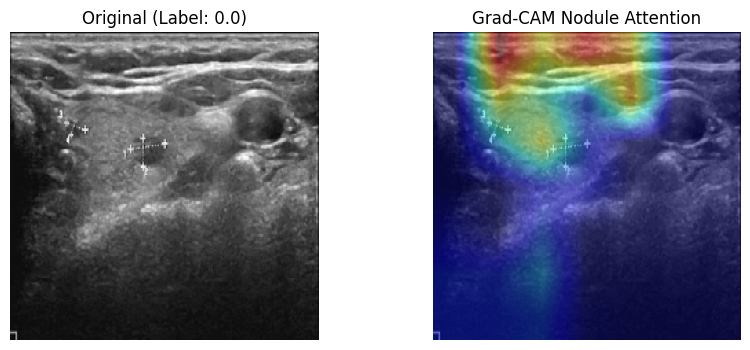

In [ ]:
import cv2
import matplotlib.pyplot as plt

def make_gradcam_heatmap(img_array, model):

    with tf.GradientTape() as tape:

        x1 = model.block1(img_array, training=False)
        x2 = model.block2(x1, training=False)

        x3 = model.block3(x2, training=False)

        x = model.pcb1(x2, x3)

        x = model.block4(x, training=False)

        x = model.pcb2(x3, x, training=False)

        x = model.block5(x, training=False)

        x = model.dwsc1(x, training=False)

        last_conv_output = model.dwsc2(x, training=False)

        x = model.gap(last_conv_output)
        x = model.dropout(x, training=False)

        preds = model.classifier(x)

        class_channel = preds[:, 0]

    grads = tape.gradient(class_channel, last_conv_output)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    last_conv_output = last_conv_output[0]

    heatmap = last_conv_output @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

test_gen_new.reset()
sample_batch_x, sample_batch_y = next(test_gen_new)
img_sample = sample_batch_x[0:1] 
label_sample = sample_batch_y[0]

last_conv_name = None
for layer in reversed(model.layers):
    if isinstance(layer, DWSCBlock) or "depthwise_separable_conv" in layer.name:
        last_conv_name = layer.name
        break

if last_conv_name:
    heatmap = make_gradcam_heatmap(img_sample, model)

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img_sample[0])
    plt.title(f"Original (Label: {label_sample})")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img_sample[0])
    resized_heatmap = cv2.resize(heatmap, (img_size[0], img_size[1]))
    plt.imshow(resized_heatmap, alpha=0.4, cmap='jet')
    plt.title("Grad-CAM Nodule Attention")
    plt.axis('off')
    plt.show()
else:
    print("Could not find a valid convolutional layer for Grad-CAM.")